# Relações Fundamentais

**Módulo:** 05 – Trigonometria (3º notebook do módulo)

**Pré-requisitos:** [`0501a_arcos_e_angulos.ipynb`](0501a_arcos_e_angulos.ipynb) (ciclo trigonométrico, radianos) e [`0502a_funcoes_circulares.ipynb`](0502a_funcoes_circulares.ipynb) (definição, domínio e imagem das seis funções circulares)

**Objetivos de aprendizagem:**
- Deduzir a relação fundamental sen²x + cos²x = 1 a partir do Teorema de Pitágoras aplicado ao ciclo trigonométrico.
- Obter as relações de quociente (tg, cotg) e as relações derivadas (sec², cossec²) a partir das relações já conhecidas.
- Simplificar expressões trigonométricas usando as relações fundamentais e derivadas.
- Demonstrar identidades trigonométricas simples, justificando cada passo do raciocínio.

**Tempo estimado:** 75 a 95 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/05_trigonometria/0503a_relacoes_fundamentais.ipynb)

## O avião que não pode "perder" velocidade

Um avião decola subindo em um ângulo de 20° em relação ao solo, a uma velocidade de 250 km/h. Você quer separar essa velocidade em duas partes: quanto ele avança na horizontal e quanto ele sobe na vertical. Usando seno e cosseno para fazer essa separação (como se aprendeu em `0502a_funcoes_circulares`), como garantir que você não "perdeu" nem "inventou" velocidade no processo — ou seja, que as duas partes, somadas de volta, reproduzem exatamente a velocidade original?

Ainda não temos uma forma de *verificar* isso. É exatamente essa verificação que a relação fundamental da trigonometria oferece — e o problema é resolvido por completo no Bloco 2.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sp
import ipywidgets as widgets
from IPython.display import display

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    '''Aplica o estilo Nord padrão a um eixo do matplotlib.'''
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)

## 1. Seis Funções, Duas Relações

No notebook anterior (`0502a_funcoes_circulares`), sen, cos, tg, cotg, sec e cossec foram definidas como seis funções separadas, cada uma com seu próprio domínio, imagem e período. Tratá-las como seis objetos independentes funciona, mas é trabalhoso: toda vez que se quer simplificar uma expressão ou provar algo, seria preciso lembrar de seis definições ao mesmo tempo.

Este notebook mostra que isso não é necessário. Todas as seis funções podem ser reduzidas a apenas duas — sen(x) e cos(x) — através de duas famílias de relações:

- uma relação **"pitagórica"**, que conecta sen²x e cos²x (Bloco 2), da qual saem duas relações derivadas envolvendo sec e cossec (Bloco 4);
- relações **"de quociente"**, que escrevem tg e cotg em termos de sen e cos (Bloco 3).

É essa redução que torna possível simplificar expressões trigonométricas complicadas e demonstrar identidades — os dois últimos blocos deste notebook.

In [2]:
angulo_exemplo_graus = 50
angulo_exemplo_rad = math.radians(angulo_exemplo_graus)

sen_x = math.sin(angulo_exemplo_rad)
cos_x = math.cos(angulo_exemplo_rad)

tabela_comparacao = pd.DataFrame({
    "funcao": ["sen(x)", "cos(x)", "tg(x)", "cotg(x)", "sec(x)", "cossec(x)"],
    "direto (math)": [
        math.sin(angulo_exemplo_rad),
        math.cos(angulo_exemplo_rad),
        math.tan(angulo_exemplo_rad),
        1 / math.tan(angulo_exemplo_rad),
        1 / math.cos(angulo_exemplo_rad),
        1 / math.sin(angulo_exemplo_rad),
    ],
    "a partir de sen e cos": [
        sen_x,
        cos_x,
        sen_x / cos_x,
        cos_x / sen_x,
        1 / cos_x,
        1 / sen_x,
    ],
})
tabela_comparacao.round(4)

,funcao,direto (math),a partir de sen e cos
0,sen(x),0.7660,0.7660
1,cos(x),0.6428,0.6428
2,tg(x),1.1918,1.1918
3,cotg(x),0.8391,0.8391
4,sec(x),1.5557,1.5557
5,cossec(x),1.3054,1.3054


📎 **Conexão:** essa tabela reconstrói as seis funções vistas em `0502a_funcoes_circulares` — mas agora partindo de apenas dois valores (sen e cos), não de seis definições independentes.

**Pergunta de checagem:** se você soubesse apenas o valor de sen(x) e cos(x) para um certo x, seria possível calcular as outras quatro funções circulares desse mesmo x?

## 2. Relação Fundamental (sen²x + cos²x = 1)

Considere um arco x qualquer e o ponto correspondente no ciclo trigonométrico: (cos x, sen x). Como esse ponto está sobre uma circunferência de raio 1, ele satisfaz a equação do ciclo trigonométrico:

**x² + y² = 1**

Substituindo x = cos x e y = sen x (as coordenadas do próprio ponto):

📌 **Relação fundamental da trigonometria:**

**sen²x + cos²x = 1**, para qualquer x real.

Geometricamente, isso é só o Teorema de Pitágoras aplicado ao triângulo retângulo formado pelos catetos cos x e sen x e pela hipotenusa 1 (o raio do ciclo trigonométrico) — por isso a relação vale sempre, não só para ângulos agudos de um triângulo "de verdade".

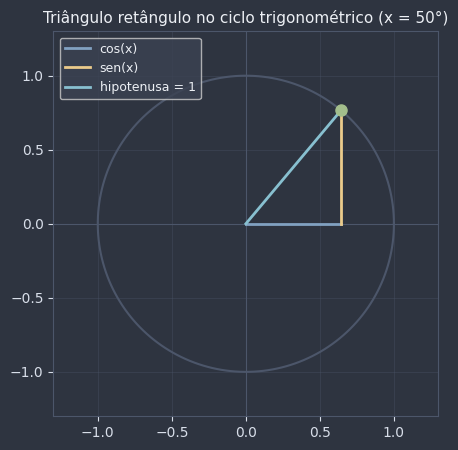

In [3]:
angulo_triangulo_graus = 50
angulo_triangulo_rad = math.radians(angulo_triangulo_graus)
x_p, y_p = math.cos(angulo_triangulo_rad), math.sin(angulo_triangulo_rad)

fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)

angulos_completos = np.linspace(0, 2 * math.pi, 200)
ax.plot(np.cos(angulos_completos), np.sin(angulos_completos), color=NORD_LINHA, linewidth=1.5)
ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
ax.axvline(0, color=NORD_LINHA, linewidth=0.8)

# catetos do triangulo retangulo: cos(x) na horizontal, sen(x) na vertical
ax.plot([0, x_p], [0, 0], color=COR_SECUNDARIA, linewidth=2, label="cos(x)")
ax.plot([x_p, x_p], [0, y_p], color=COR_AVISO, linewidth=2, label="sen(x)")
# hipotenusa: raio 1
ax.plot([0, x_p], [0, y_p], color=COR_PONTO, linewidth=2, label="hipotenusa = 1")
ax.plot(x_p, y_p, "o", color=COR_DESTAQUE, markersize=8)

ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.set_aspect("equal")
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, loc="upper left", fontsize=9)
ax.set_title(
    f"Triângulo retângulo no ciclo trigonométrico (x = {angulo_triangulo_graus}°)",
    color=NORD_TEXTO, fontsize=11,
)
plt.show()

In [4]:
angulos_teste_graus = [10, 45, 75, 130, 200, 310]

tabela_relacao_fundamental = pd.DataFrame({
    "x (graus)": angulos_teste_graus,
    "sen(x)": [round(math.sin(math.radians(a)), 4) for a in angulos_teste_graus],
    "cos(x)": [round(math.cos(math.radians(a)), 4) for a in angulos_teste_graus],
    "sen^2(x) + cos^2(x)": [
        round(math.sin(math.radians(a)) ** 2 + math.cos(math.radians(a)) ** 2, 4)
        for a in angulos_teste_graus
    ],
})
tabela_relacao_fundamental

,x (graus),sen(x),cos(x),sen^2(x) + cos^2(x)
0,10,0.1736,0.9848,1.0
1,45,0.7071,0.7071,1.0
2,75,0.9659,0.2588,1.0
3,130,0.7660,-0.6428,1.0
4,200,-0.3420,-0.9397,1.0
5,310,-0.7660,0.6428,1.0


🎯 **Aplicação prática — o avião do gancho, resolvido:** decompondo a velocidade v em componente horizontal v·cos θ e componente vertical v·sen θ, a relação fundamental garante que

(v·cos θ)² + (v·sen θ)² = v²·(cos²θ + sen²θ) = v²·1 = v²

ou seja, a velocidade original é sempre recuperada corretamente, qualquer que seja o ângulo θ — não é possível "perder" nem "inventar" velocidade decompondo dessa forma.

In [ ]:
theta_sym, v_sym = sp.symbols("theta v", real=True, positive=True)

componente_horizontal_sym = v_sym * sp.cos(theta_sym)
componente_vertical_sym = v_sym * sp.sin(theta_sym)

soma_quadrados_sym = sp.simplify(componente_horizontal_sym**2 + componente_vertical_sym**2)
print(f"(v*cos(theta))^2 + (v*sen(theta))^2 = {soma_quadrados_sym}")

# conferindo com os números do avião
velocidade_aviao = 250  # km/h
angulo_decolagem_graus = 20
angulo_decolagem_rad = math.radians(angulo_decolagem_graus)

velocidade_horizontal = velocidade_aviao * math.cos(angulo_decolagem_rad)
velocidade_vertical = velocidade_aviao * math.sin(angulo_decolagem_rad)
velocidade_recuperada = math.sqrt(velocidade_horizontal**2 + velocidade_vertical**2)

print(f"componente horizontal: {velocidade_horizontal:.2f} km/h")
print(f"componente vertical:   {velocidade_vertical:.2f} km/h")
print(f"velocidade recuperada: {velocidade_recuperada:.2f} km/h (original: {velocidade_aviao} km/h)")

(v*cos(theta))^2 + (v*sen(theta))^2 = v**2
componente horizontal: 234.92 km/h
componente vertical:   85.51 km/h
velocidade recuperada: 250.00 km/h (original: 250 km/h)


🕹️ **Widget interativo:** mova o slider de ângulo e observe o triângulo retângulo desenhado ao vivo dentro do ciclo trigonométrico, com o valor de sen²x + cos²x recalculado a cada movimento.

In [6]:
def triangulo_interativo(angulo_graus: float) -> None:
    angulo_rad = math.radians(angulo_graus)
    x_p = math.cos(angulo_rad)
    y_p = math.sin(angulo_rad)
    relacao = round(math.sin(angulo_rad) ** 2 + math.cos(angulo_rad) ** 2, 6)

    fig, ax = plt.subplots(figsize=(5, 5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)

    angulos_completos = np.linspace(0, 2 * math.pi, 200)
    ax.plot(np.cos(angulos_completos), np.sin(angulos_completos), color=NORD_LINHA, linewidth=1.5)
    ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
    ax.axvline(0, color=NORD_LINHA, linewidth=0.8)

    ax.plot([0, x_p], [0, 0], color=COR_SECUNDARIA, linewidth=2)
    ax.plot([x_p, x_p], [0, y_p], color=COR_AVISO, linewidth=2)
    ax.plot([0, x_p], [0, y_p], color=COR_PONTO, linewidth=2)
    ax.plot(x_p, y_p, "o", color=COR_DESTAQUE, markersize=10)

    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_aspect("equal")
    ax.set_title(
        f"sen²({angulo_graus}°) + cos²({angulo_graus}°) = {relacao}",
        color=NORD_TEXTO, fontsize=11,
    )
    plt.show()


widgets.interact(
    triangulo_interativo,
    angulo_graus=widgets.IntSlider(min=0, max=360, step=1, value=50, description="ângulo (°)"),
)

interactive(children=(IntSlider(value=50, description='ângulo (°)', max=360), Output()), _dom_classes=('widget…

<function __main__.triangulo_interativo(angulo_graus: float) -> None>

**Pergunta de checagem:** por que a relação sen²x + cos²x = 1 vale para qualquer ângulo x, e não só para ângulos agudos de um triângulo retângulo?

📖 **Leitura complementar:** [Teorema de Pitágoras](https://pt.wikipedia.org/wiki/Teorema_de_Pit%C3%A1goras) · [Vetor (matemática)](https://pt.wikipedia.org/wiki/Vetor_(matem%C3%A1tica))

## 3. Relações de Quociente (tg e cotg)

Em `0502a_funcoes_circulares`, tangente e cotangente já foram definidas como razões:

**tg x = sen x / cos x** (definida quando cos x ≠ 0)

**cotg x = cos x / sen x = 1 / tg x** (definida quando sen x ≠ 0)

O que muda agora é a perspectiva: em vez de definições isoladas, essas são **relações** que conectam tg e cotg diretamente a sen e cos — a mesma ideia de "reduzir tudo a duas funções" do Bloco 1. As restrições de domínio (cos x ≠ 0 para tg, sen x ≠ 0 para cotg) vêm diretamente dessas razões: uma divisão por zero nunca está definida.

In [7]:
def tg_a_partir_de_sen_cos(sen_x: float, cos_x: float) -> float:
    '''Calcula a tangente a partir de sen(x) e cos(x).'''
    return sen_x / cos_x


def cotg_a_partir_de_sen_cos(sen_x: float, cos_x: float) -> float:
    '''Calcula a cotangente a partir de sen(x) e cos(x).'''
    return cos_x / sen_x


angulos_quociente_graus = [20, 40, 65, 110, 250]

tabela_quociente = pd.DataFrame({
    "x (graus)": angulos_quociente_graus,
    "tg(x) via math.tan": [round(math.tan(math.radians(a)), 4) for a in angulos_quociente_graus],
    "tg(x) via sen/cos": [
        round(tg_a_partir_de_sen_cos(math.sin(math.radians(a)), math.cos(math.radians(a))), 4)
        for a in angulos_quociente_graus
    ],
    "cotg(x) via sen/cos": [
        round(cotg_a_partir_de_sen_cos(math.sin(math.radians(a)), math.cos(math.radians(a))), 4)
        for a in angulos_quociente_graus
    ],
})
tabela_quociente

,x (graus),tg(x) via math.tan,tg(x) via sen/cos,cotg(x) via sen/cos
0,20,0.3640,0.3640,2.7475
1,40,0.8391,0.8391,1.1918
2,65,2.1445,2.1445,0.4663
3,110,-2.7475,-2.7475,-0.3640
4,250,2.7475,2.7475,0.3640


💡 **Dica:** sempre que uma expressão envolver tangente ou cotangente e travar, uma boa estratégia é reescrever tudo em termos de seno e cosseno — é exatamente essa ideia que sustenta os Blocos 6 e 7.

**Pergunta de checagem:** por que tg x não está definida quando cos x = 0? O que aconteceria com a divisão?

## 4. Relações Derivadas (sec²x = 1 + tg²x; cossec²x = 1 + cotg²x)

As relações a seguir não são "novas" — são consequências diretas da relação fundamental, obtidas dividindo os dois lados de sen²x + cos²x = 1 por cos²x ou por sen²x.

**Dividindo por cos²x** (válido quando cos x ≠ 0):

sen²x/cos²x + cos²x/cos²x = 1/cos²x  →  tg²x + 1 = sec²x

**Dividindo por sen²x** (válido quando sen x ≠ 0):

sen²x/sen²x + cos²x/sen²x = 1/sen²x  →  1 + cotg²x = cossec²x

In [8]:
angulos_derivadas_graus = [15, 50, 95, 140, 220, 305]
tolerancia = 1e-9

for a in angulos_derivadas_graus:
    x = math.radians(a)
    sec2 = 1 / math.cos(x) ** 2
    tg2 = math.tan(x) ** 2
    cossec2 = 1 / math.sin(x) ** 2
    cotg2 = (math.cos(x) / math.sin(x)) ** 2

    assert abs(sec2 - (1 + tg2)) < tolerancia, f"falhou para x={a}°: sec^2 != 1+tg^2"
    assert abs(cossec2 - (1 + cotg2)) < tolerancia, f"falhou para x={a}°: cossec^2 != 1+cotg^2"

    print(
        f"x = {a:>3}°   sec²x = {sec2:.4f} = 1+tg²x = {1 + tg2:.4f}   "
        f"cossec²x = {cossec2:.4f} = 1+cotg²x = {1 + cotg2:.4f}"
    )

print("\nas duas relações derivadas valem para todos os ângulos testados.")

x =  15°   sec²x = 1.0718 = 1+tg²x = 1.0718   cossec²x = 14.9282 = 1+cotg²x = 14.9282
x =  50°   sec²x = 2.4203 = 1+tg²x = 2.4203   cossec²x = 1.7041 = 1+cotg²x = 1.7041
x =  95°   sec²x = 131.6461 = 1+tg²x = 131.6461   cossec²x = 1.0077 = 1+cotg²x = 1.0077
x = 140°   sec²x = 1.7041 = 1+tg²x = 1.7041   cossec²x = 2.4203 = 1+cotg²x = 2.4203
x = 220°   sec²x = 1.7041 = 1+tg²x = 1.7041   cossec²x = 2.4203 = 1+cotg²x = 2.4203
x = 305°   sec²x = 3.0396 = 1+tg²x = 3.0396   cossec²x = 1.4903 = 1+cotg²x = 1.4903

as duas relações derivadas valem para todos os ângulos testados.


⚠️ **Erro comum:** dividir a relação fundamental por cos²x ou sen²x sem checar se esses valores são diferentes de zero. A divisão por cos²x (para obter sec²x = 1 + tg²x) deixa de fazer sentido exatamente onde cos x = 0 — os mesmos pontos onde tg x e sec x já não estão definidas. O mesmo vale para a divisão por sen²x, nos pontos onde sen x = 0.

**Pergunta de checagem:** para obter cossec²x = 1 + cotg²x, por qual expressão dividimos a relação fundamental?

## 5. Identidades

📌 **Definição formal:** uma **identidade trigonométrica** é uma igualdade entre duas expressões que vale para **todo** valor de x no domínio comum das expressões envolvidas — não só para alguns valores especiais.

Isso é diferente de uma **equação trigonométrica**, como sen x = 0,5, que vale apenas para alguns valores específicos de x (nesse caso, x = 30° + k·360° ou x = 150° + k·360°, k inteiro) — a maioria dos valores de x não satisfaz essa igualdade.

Todas as relações vistas até aqui são identidades:

- sen²x + cos²x = 1
- tg x = sen x / cos x
- sec²x = 1 + tg²x

Cada uma delas vale para *qualquer* x do domínio — é exatamente isso que as torna ferramentas confiáveis para simplificar expressões e demonstrar outras identidades.

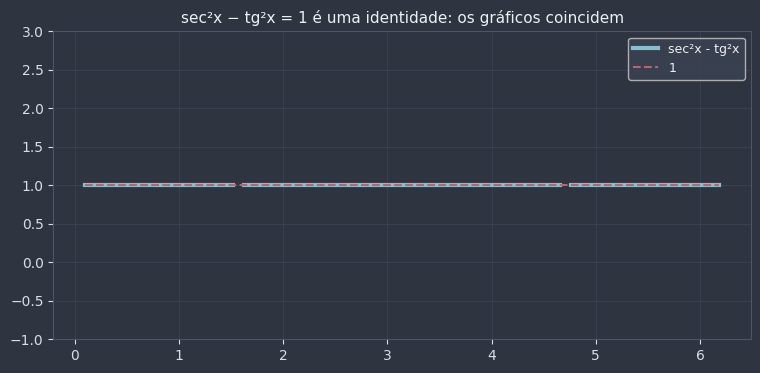

In [9]:
x_vals = np.linspace(0.1, 2 * math.pi - 0.1, 400)
# removendo pontos próximos das assíntotas de tg/sec (cos(x) = 0)
cos_vals = np.cos(x_vals)
lado_esquerdo = np.where(np.abs(cos_vals) > 0.05, 1 / cos_vals**2 - np.tan(x_vals) ** 2, np.nan)
lado_direito = np.ones_like(x_vals)

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(x_vals, lado_esquerdo, color=COR_PONTO, linewidth=3, label="sec²x - tg²x")
ax.plot(x_vals, lado_direito, color=COR_ALERTA, linewidth=1.5, linestyle="--", label="1")
ax.set_ylim(-1, 3)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=9)
ax.set_title("sec²x − tg²x = 1 é uma identidade: os gráficos coincidem", color=NORD_TEXTO, fontsize=11)
plt.show()

📌 A diferença entre identidade e equação está em *quantos* valores de x satisfazem a igualdade: todo o domínio (identidade) ou apenas alguns pontos (equação). Testar valores e plotar os dois lados, como acima, é uma boa forma de reunir *evidência* de que algo é uma identidade — mas não substitui uma demonstração algébrica (Bloco 7).

**Pergunta de checagem:** sen x = 0 é uma identidade ou uma equação? E sen²x + cos²x = 1?

📖 **Leitura complementar:** [Identidade (matemática)](https://pt.wikipedia.org/wiki/Identidade_(matem%C3%A1tica)) · [Identidades trigonométricas](https://pt.wikipedia.org/wiki/Identidades_trigonom%C3%A9tricas)

## 6. Simplificação de Expressões Trigonométricas

Não existe uma receita única para simplificar uma expressão trigonométrica, mas três estratégias resolvem a maioria dos casos:

1. **Reescrever tudo em termos de sen e cos** quando não souber por onde começar — isso reduz o número de "peças" diferentes na expressão.
2. **Procurar padrões conhecidos** — um sen²x + cos²x escondido, um sec²x − tg²x, um sen x/cos x que é só tg x disfarçada.
3. **Fatorar** quando possível, para revelar um desses padrões.

Um exemplo simples: tg x · cos x = (sen x / cos x) · cos x = sen x — aplicando só a estratégia 1.

Um exemplo um pouco mais elaborado: sec²x − tg²x. Reescrevendo em sen e cos, 1/cos²x − sen²x/cos²x = (1 − sen²x)/cos²x = cos²x/cos²x = 1 — usando a estratégia 1 e depois reconhecendo, no numerador, a relação fundamental "de trás para frente" (1 − sen²x = cos²x).

In [10]:
x_symbol = sp.symbols("x", real=True)
expressao = sp.sin(x_symbol) ** 2 + sp.cos(x_symbol) ** 2 + sp.tan(x_symbol) ** 2 * sp.cos(x_symbol) ** 2
expressao_simplificada = sp.simplify(expressao)

print(f"expressão original:     {expressao}")
print(f"simplificada por sympy: {expressao_simplificada}")

expressão original:     sin(x)**2 + cos(x)**2*tan(x)**2 + cos(x)**2
simplificada por sympy: sin(x)**2 + 1


💡 **Dica:** quando travar em uma simplificação, a estratégia mais confiável costuma ser voltar tudo para seno e cosseno — foi assim que os dois exemplos acima foram resolvidos. Repare também que nem toda simplificação termina em uma constante: acima, o resultado ainda depende de x, mas ficou bem mais simples do que a expressão original.

**Pergunta de checagem:** qual das relações vistas neste notebook ajudaria a simplificar a expressão sen²x + cos²x + tg²x·cos²x?

## 7. Demonstração de Identidade

Demonstrar uma identidade significa partir de um dos lados da igualdade e, usando relações já conhecidas, transformá-lo passo a passo até chegar exatamente no outro lado. Uma regra importante: **só se opera em um lado por vez** — diferente de resolver uma equação, aqui não se soma nem multiplica os dois lados simultaneamente, porque isso poderia "forçar" uma igualdade falsa a parecer verdadeira.

**Demonstração:** (sen x + cos x)² = 1 + 2·sen x·cos x

| Passo | Expressão | Justificativa |
|---|---|---|
| 1 | (sen x + cos x)² | lado esquerdo, ponto de partida |
| 2 | sen²x + 2·sen x·cos x + cos²x | expandindo o quadrado da soma, (a+b)² = a² + 2ab + b² |
| 3 | (sen²x + cos²x) + 2·sen x·cos x | reorganizando os termos |
| 4 | 1 + 2·sen x·cos x | aplicando a relação fundamental (Bloco 2) |

Como o passo 4 é exatamente o lado direito, a identidade está demonstrada.

In [11]:
x_vals_demo = np.linspace(0, 2 * math.pi, 25)
lado_esquerdo_demo = (np.sin(x_vals_demo) + np.cos(x_vals_demo)) ** 2
lado_direito_demo = 1 + 2 * np.sin(x_vals_demo) * np.cos(x_vals_demo)

diferenca_maxima = np.max(np.abs(lado_esquerdo_demo - lado_direito_demo))
print(f"maior diferença entre os dois lados: {diferenca_maxima:.2e}")
assert diferenca_maxima < 1e-9, "os dois lados deveriam ser numericamente iguais"
print("identidade confirmada numericamente para todos os x testados.")

maior diferença entre os dois lados: 4.44e-16
identidade confirmada numericamente para todos os x testados.


🕵️ **Curiosidade histórica:** antes das calculadoras, identidades como esta eram essenciais para calcular valores de funções trigonométricas a partir de tabelas já conhecidas — técnica usada desde a Antiguidade, como nas tábuas de cordas de Ptolomeu (século II), que listavam o comprimento de cordas de uma circunferência para cada ângulo e permitiam obter outros valores por manipulação algébrica, sem recalcular tudo do zero.

**Pergunta de checagem:** ao demonstrar uma identidade, por que não é permitido operar dos dois lados da igualdade ao mesmo tempo, como se faz ao resolver uma equação?

## Resumo — cheat sheet

| Conceito | Ideia-chave |
|---|---|
| Relação fundamental | sen²x + cos²x = 1, para qualquer x real |
| Relações de quociente | tg x = sen x / cos x (cos x ≠ 0); cotg x = cos x / sen x = 1/tg x (sen x ≠ 0) |
| Relações derivadas | sec²x = 1 + tg²x (cos x ≠ 0); cossec²x = 1 + cotg²x (sen x ≠ 0) |
| Identidade x equação | identidade vale para todo x do domínio; equação vale só para alguns valores de x |
| Simplificar | (1) reescrever em sen/cos; (2) procurar padrões conhecidos; (3) fatorar |
| Demonstrar | transformar um lado da igualdade até chegar no outro, um passo de cada vez, sem operar nos dois lados simultaneamente |

## Exercícios

**Básico**
1. Verificar numericamente, com `assert`, que sen²x + cos²x = 1 para vários valores de x.
2. Calcular tg, cotg, sec e cossec de um ângulo a partir apenas dos valores de sen e cos fornecidos.

**Intermediário**
3. Simplificar quatro expressões trigonométricas usando as relações vistas.
4. Demonstrar numericamente uma identidade curta.

**Desafio**
5. Demonstrar numericamente uma identidade trigonométrica mais elaborada.
6. Problema aplicado: decompor uma força sobre um plano inclinado e verificar a decomposição com a relação fundamental.

### Básico

In [ ]:
# Exercício Básico 1: verifique numericamente que sen²(x) + cos²(x) = 1 para os
# ângulos abaixo (em graus). Guarde o resultado como uma lista de booleanos
# (True se a igualdade vale, com tolerância de 1e-9), na mesma ordem dos ângulos.
angulos_exercicio1 = [17, 63, 128, 194, 275, 340]
resultados_exercicio1 = ...  # ex: [True, True, ...]

print(resultados_exercicio1)

In [ ]:
# Verificação
esperado_exercicio1 = [
    abs(math.sin(math.radians(a)) ** 2 + math.cos(math.radians(a)) ** 2 - 1) < 1e-9
    for a in angulos_exercicio1
]
assert resultados_exercicio1 == esperado_exercicio1, (
    "Tente de novo, revise: calcule sen(x)^2 + cos(x)^2 para cada ângulo e compare "
    "com 1 usando uma tolerância pequena (seção 2 - Relação Fundamental)."
)
print("Certo!")

In [ ]:
# Exercício Básico 2: sabendo que sen(x) = 0.6 e cos(x) = 0.8 para um certo ângulo x,
# calcule tg(x), cotg(x), sec(x) e cossec(x) a partir apenas desses dois valores.
# Guarde a resposta como uma tupla (tg_x, cotg_x, sec_x, cossec_x), cada valor
# arredondado a 4 casas decimais.
sen_exercicio2 = 0.6
cos_exercicio2 = 0.8
respostas_exercicio2 = ...  # ex: (tg_x, cotg_x, sec_x, cossec_x)

print(respostas_exercicio2)

In [ ]:
# Verificação
esperado_exercicio2 = (
    round(sen_exercicio2 / cos_exercicio2, 4),
    round(cos_exercicio2 / sen_exercicio2, 4),
    round(1 / cos_exercicio2, 4),
    round(1 / sen_exercicio2, 4),
)
assert respostas_exercicio2 == esperado_exercicio2, (
    "Tente de novo, revise: tg = sen/cos, cotg = cos/sen, sec = 1/cos, cossec = 1/sen "
    "(seção 3 e 4 - Relações de Quociente e Relações Derivadas)."
)
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 3: cada expressão abaixo simplifica para uma função mais
# simples. Para cada uma, escreva a forma simplificada usando exatamente um destes
# textos: "1", "sen(x)", "cos(x)" ou "tg(x)". Guarde as respostas como uma lista de
# strings, na mesma ordem das expressões.
# (a) tg(x) * cos(x)
# (b) sec^2(x) - tg^2(x)
# (c) sen^2(x) * (1 + cotg^2(x))
# (d) (1 - cos^2(x)) / sen(x)
respostas_exercicio3 = ...  # ex: [resp_a, resp_b, resp_c, resp_d]

print(respostas_exercicio3)

In [ ]:
# Verificação
funcoes_candidatas = {
    "1": lambda x: 1.0,
    "sen(x)": math.sin,
    "cos(x)": math.cos,
    "tg(x)": math.tan,
}

expressoes_exercicio3 = [
    lambda x: math.tan(x) * math.cos(x),
    lambda x: (1 / math.cos(x)) ** 2 - math.tan(x) ** 2,
    lambda x: math.sin(x) ** 2 * (1 + (math.cos(x) / math.sin(x)) ** 2),
    lambda x: (1 - math.cos(x) ** 2) / math.sin(x),
]

x_testes = [0.3, 0.9, 1.7, 2.4]

assert len(respostas_exercicio3) == 4, (
    "Tente de novo, revise: a resposta deve ter 4 itens, um para cada expressão "
    "(seção 6 - Simplificação de Expressões Trigonométricas)."
)

for indice, (expressao, resposta) in enumerate(zip(expressoes_exercicio3, respostas_exercicio3)):
    assert resposta in funcoes_candidatas, (
        f"Tente de novo, revise: a resposta do item {indice + 1} deve ser exatamente "
        '"1", "sen(x)", "cos(x)" ou "tg(x)" (seção 6 - Simplificação de Expressões Trigonométricas).'
    )
    candidata = funcoes_candidatas[resposta]
    for x in x_testes:
        assert abs(expressao(x) - candidata(x)) < 1e-9, (
            f'Tente de novo, revise: o item {indice + 1} não simplifica para "{resposta}" '
            "(seção 6 - Simplificação de Expressões Trigonométricas)."
        )

print("Certo!")

In [ ]:
# Exercício Intermediário 4: demonstre (numericamente) que a identidade
# tg(x) * cossec(x) = sec(x) vale, testando vários valores de x. Guarde o resultado
# como um valor booleano (True se a maior diferença entre os dois lados, entre os x
# testados, for menor que 1e-9) em identidade_valida_exercicio4.
x_testes_exercicio4 = [0.2, 0.8, 1.3, 2.1, 2.9, 4.0]
identidade_valida_exercicio4 = ...

print(identidade_valida_exercicio4)

In [ ]:
# Verificação
diferencas_exercicio4 = [
    abs(math.tan(x) * (1 / math.sin(x)) - 1 / math.cos(x)) for x in x_testes_exercicio4
]
esperado_exercicio4 = max(diferencas_exercicio4) < 1e-9
assert identidade_valida_exercicio4 == esperado_exercicio4, (
    "Tente de novo, revise: calcule tg(x)*cossec(x) e sec(x) para cada x testado, e "
    "verifique se a maior diferença entre os dois lados é menor que 1e-9 "
    "(seção 3 e 4 - Relações de Quociente e Relações Derivadas)."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 5: demonstre que a identidade
# sen^4(x) - cos^4(x) = sen^2(x) - cos^2(x) vale, testando vários valores de x.
# Guarde o resultado como um valor booleano em identidade_valida_exercicio5 (True se
# a maior diferença entre os dois lados, entre os x testados, for menor que 1e-9).
x_testes_exercicio5 = [0.1, 0.7, 1.4, 2.2, 3.5, 5.0]
identidade_valida_exercicio5 = ...

print(identidade_valida_exercicio5)

In [ ]:
# Verificação
diferencas_exercicio5 = [
    abs((math.sin(x) ** 4 - math.cos(x) ** 4) - (math.sin(x) ** 2 - math.cos(x) ** 2))
    for x in x_testes_exercicio5
]
esperado_exercicio5 = max(diferencas_exercicio5) < 1e-9
assert identidade_valida_exercicio5 == esperado_exercicio5, (
    "Tente de novo, revise: fatore sen^4x - cos^4x como uma diferença de quadrados, "
    "(sen^2x - cos^2x)(sen^2x + cos^2x), e aplique a relação fundamental no segundo "
    "fator (seção 2 - Relação Fundamental)."
)
print("Certo!")

In [ ]:
# Exercício Desafio 6: um bloco está sobre um plano inclinado de ângulo theta = 35°
# em relação à horizontal. Uma força de módulo F = 120 N atua sobre o bloco, na
# direção da inclinação. Decomponha essa força em uma componente paralela ao plano
# (F*cos(theta)) e uma componente perpendicular ao plano (F*sen(theta)), e use a
# relação fundamental para verificar que essas componentes reproduzem o módulo
# original da força. Guarde o módulo recuperado (em N, arredondado a 2 casas
# decimais) em modulo_recuperado_exercicio6.
forca_N = 120
angulo_plano_graus = 35
modulo_recuperado_exercicio6 = ...

print(f"{modulo_recuperado_exercicio6} N")

In [ ]:
# Verificação
angulo_plano_rad = math.radians(angulo_plano_graus)
componente_paralela = forca_N * math.cos(angulo_plano_rad)
componente_perpendicular = forca_N * math.sin(angulo_plano_rad)
esperado_exercicio6 = round(math.sqrt(componente_paralela**2 + componente_perpendicular**2), 2)
assert modulo_recuperado_exercicio6 == esperado_exercicio6, (
    "Tente de novo, revise: decomponha a força em F*cos(theta) e F*sen(theta), eleve "
    "ao quadrado, some e tire a raiz — a relação fundamental garante que o resultado "
    "é o módulo original (seção 2 - Relação Fundamental)."
)
print("Certo!")

## Glossário do bloco

| Termo | Definição |
|---|---|
| Relação fundamental | sen²x + cos²x = 1, válida para todo x real |
| Relações de quociente | tg x = sen x/cos x; cotg x = cos x/sen x |
| Relações derivadas | sec²x = 1 + tg²x; cossec²x = 1 + cotg²x |
| Identidade trigonométrica | igualdade válida para todo x do domínio comum das expressões |
| Equação trigonométrica | igualdade válida apenas para alguns valores específicos de x |

## Conexões

**Isso depende de:**
- [`0501a_arcos_e_angulos.ipynb`](0501a_arcos_e_angulos.ipynb) (ciclo trigonométrico, radianos)
- [`0502a_funcoes_circulares.ipynb`](0502a_funcoes_circulares.ipynb) (definição, domínio e imagem das seis funções circulares)

**Isso será usado em:**
- 📌 Redução ao 1º Quadrante (identidades e sinais das funções para reduzir arcos de qualquer quadrante ao primeiro)
- 📌 Transformações (as fórmulas de adição e multiplicação de arcos se apoiam diretamente na relação fundamental)
- 📌 Equações Trigonométricas (simplificar uma equação antes de resolvê-la frequentemente exige as relações vistas aqui)
- [`11_limite_integral_e_derivada/`](../11_limite_integral_e_derivada/) (identidades trigonométricas são usadas para simplificar expressões antes de derivar ou integrar)